In [1]:
import pickle
import re
from pathlib import Path

from langchain_community.document_loaders import TextLoader
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
from langchain_core.runnables import RunnableLambda
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
import math
import json
import hashlib
import importlib.metadata
import xml.etree.ElementTree as ET
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from tqdm.auto import tqdm
import random


/tmp/ipykernel_162382/2945073862.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


/home/yan/miniconda3/envs/LocalAgent_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Configuration

In [2]:
data_dir = Path("/home/yan/test/RAG/demo/data/trec_pm2019")
md_dir = data_dir / "trial_markdown"
index_path = Path("/home/yan/test/RAG/bm25/bm25_index.pkl")
db_dir = Path("/home/yan/test/RAG/chroma_context_db")
output_dir = Path("/home/yan/projects/BioPaster/docs/assets/trec2019/hybrid")
collection_name = "trec_2019_trials_context"
model_name = "BAAI/bge-small-en-v1.5"
device = "cuda"
candidate_count = 100
sample_size = 10
sample_seed = 42


### Load BM25

In [3]:
with index_path.open("rb") as file:
    saved_index = pickle.load(file)

documents = []
for metadata in saved_index["metadatas"]:
    document = TextLoader(str(md_dir / f"{metadata['nct_id']}.md"), encoding="utf-8").load()[0]
    document.metadata.update(metadata)
    documents.append(document)

bm25_retriever = BM25Retriever(
    vectorizer=saved_index["vectorizer"],
    docs=documents,
    preprocess_func=lambda text: re.findall(
        saved_index["token_pattern"],
        text.lower() if saved_index["lowercase"] else text,
    ),
    k=candidate_count,
)
print("BM25 documents:", len(documents))

BM25 documents: 8567


### Load vector retrieval

In [4]:
embedding_model = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs={"device": device, "local_files_only": True},
    encode_kwargs={"normalize_embeddings": True, "batch_size": 32},
)
vectorstore = Chroma(
    collection_name=collection_name,
    persist_directory=str(db_dir),
    embedding_function=embedding_model,
    create_collection_if_not_exists=False,
)
vector_retriever = vectorstore.as_retriever(
    search_kwargs={"k": candidate_count}
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Loading weights:  50%|█████     | 100/199 [00:00<00:00, 983.23it/s]


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1398.84it/s]

### Trial deduplication and RRF

In [5]:
def unique_trials(hits):
    trials = []
    seen = set()
    for document in hits:
        nct_id = document.metadata["nct_id"]
        if nct_id not in seen:
            seen.add(nct_id)
            trials.append(document)
    return trials

vector_fetch_counts = {}

def retrieve_vector_trials(query):
    total_chunks = vectorstore._collection.count()
    fetch_count = min(candidate_count, total_chunks)
    while True:
        hits = vectorstore.similarity_search(query, k=fetch_count)
        trials = unique_trials(hits)
        if len(trials) >= candidate_count:
            vector_fetch_counts[query] = fetch_count
            return trials[:candidate_count]
        if fetch_count == total_chunks:
            raise ValueError("Not enough distinct trials in the vector collection")
        fetch_count = min(fetch_count * 2, total_chunks)

vector_trial_retriever = RunnableLambda(retrieve_vector_trials)
hybrid_retriever = EnsembleRetriever(
    retrievers=[vector_trial_retriever, bm25_retriever],
    weights=[0.5, 0.5],
    c=60,
    id_key="nct_id",
)

### Topics, judgments and corpus coverage

In [6]:
qrels = defaultdict(dict)
for line in (data_dir / "qrels-treceval-trials.38.txt").read_text().splitlines():
    topic_id, _, nct_id, grade = line.split()
    qrels[topic_id][nct_id] = int(grade)

all_topics = {
    node.attrib["number"]: " ".join(
        (node.findtext(field) or "").strip()
        for field in ("disease", "gene", "demographic")
    )
    for node in ET.parse(data_dir / "topics2019.xml").getroot()
}
eligible_topic_ids = sorted((topic for topic in all_topics if topic in qrels), key=int)
selected_topic_ids = sorted(random.Random(sample_seed).sample(eligible_topic_ids, sample_size), key=int)
topics = {topic: all_topics[topic] for topic in selected_topic_ids}
collection = vectorstore._collection
vector_trial_ids = set()
for offset in range(0, collection.count(), 2000):
    batch = collection.get(limit=2000, offset=offset, include=["metadatas"])
    vector_trial_ids.update(metadata["nct_id"] for metadata in batch["metadatas"])
bm25_trial_ids = {document.metadata["nct_id"] for document in documents}
assert len(bm25_trial_ids) == len(documents)
assert bm25_trial_ids == vector_trial_ids
assert saved_index["vectorizer"].corpus_size == len(documents)
print("Topics:", len(topics))
print("Selected topics:", selected_topic_ids)
print("Topics without judgments:", sorted(set(all_topics) - set(qrels), key=int))
print("Trials in each index:", len(vector_trial_ids))
print("Vector chunks:", collection.count())

Topics: 10
Selected topics: ['2', '7', '8', '9', '15', '16', '18', '22', '24', '29']
Topics without judgments: ['32', '33']
Trials in each index: 8567
Vector chunks: 43459


### Evaluate

Retrieve 100 distinct trials from each branch. Increase the vector chunk fetch size until it covers 100 distinct NCT IDs. Fuse those two lists, then score P@10 and nDCG@10 on the first 10 trials and Recall@100 on the first 100 trials. Recall uses all positive judgments for each topic as the denominator. All reported metrics are macro averages over the sampled topics. The sample is drawn once with the configured seed, without using retrieval scores. Recall@10 is retained only in the per-topic CSV.

In [7]:
per_topic, rankings, candidates = [], [], []
for topic_id, query in tqdm(topics.items(), desc="Evaluating"):
    vector_docs = vector_trial_retriever.invoke(query)
    bm25_docs = bm25_retriever.invoke(query)
    fused_docs = hybrid_retriever.weighted_reciprocal_rank([vector_docs, bm25_docs])
    candidates.append({
        "topic": topic_id, "vector_chunks_fetched": vector_fetch_counts[query],
        "vector_trials": len(vector_docs),
        "bm25_trials": len(bm25_docs), "union_trials": len(fused_docs),
    })
    for method, result in [("Vector", vector_docs), ("BM25", bm25_docs), ("Hybrid RRF", fused_docs)]:
        ids100 = [doc.metadata["nct_id"] for doc in result[:100]]
        assert len(ids100) == 100 and len(set(ids100)) == 100
        relevant_at_100 = sum(qrels[topic_id].get(nct_id, 0) > 0 for nct_id in ids100)
        ids = ids100[:10]
        assert len(ids) == 10 and len(set(ids)) == 10
        grades = [qrels[topic_id].get(nct_id, 0) for nct_id in ids]
        positive_count = sum(grade > 0 for grade in qrels[topic_id].values())
        ideal = sorted(qrels[topic_id].values(), reverse=True)[:10]
        dcg = sum((2 ** grade - 1) / math.log2(rank + 1) for rank, grade in enumerate(grades, 1))
        idcg = sum((2 ** grade - 1) / math.log2(rank + 1) for rank, grade in enumerate(ideal, 1))
        per_topic.append({
            "topic": topic_id, "query": query, "method": method,
            "relevant_at_10": sum(grade > 0 for grade in grades),
            "relevant_total": positive_count,
            "relevant_at_100": relevant_at_100,
            "p10": sum(grade > 0 for grade in grades) / 10,
            "ndcg10": dcg / idcg if idcg else None,
            "recall10": sum(grade > 0 for grade in grades) / positive_count if positive_count else None,
            "recall100": relevant_at_100 / positive_count if positive_count else None,
        })
        for rank, doc in enumerate(result[:100], 1):
            nct_id = doc.metadata["nct_id"]
            rankings.append({
                "topic": topic_id, "method": method, "rank": rank,
                "nct_id": nct_id, "grade": qrels[topic_id].get(nct_id, "unjudged"),
            })

per_topic = pd.DataFrame(per_topic)
rankings = pd.DataFrame(rankings)
methods = ["Vector", "BM25", "Hybrid RRF"]
metric_names = ["p10", "ndcg10", "recall100"]
comparison = per_topic.groupby("method")[metric_names].mean().loc[methods]
display(comparison)
display(pd.DataFrame(candidates))


Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]


Evaluating:  10%|█         | 1/10 [00:00<00:04,  1.88it/s]


Evaluating:  20%|██        | 2/10 [00:00<00:02,  3.36it/s]


Evaluating:  40%|████      | 4/10 [00:00<00:01,  5.26it/s]


Evaluating:  50%|█████     | 5/10 [00:01<00:00,  5.95it/s]

...


Evaluating:  90%|█████████ | 9/10 [00:01<00:00,  7.54it/s]


Evaluating: 100%|██████████| 10/10 [00:01<00:00,  7.48it/s]


Evaluating: 100%|██████████| 10/10 [00:01<00:00,  6.05it/s]

,p10,ndcg10,recall100
method,,,
Vector,0.48,0.435636,0.386942
BM25,0.63,0.572556,0.423669
Hybrid RRF,0.59,0.539402,0.442028


,topic,vector_chunks_fetched,vector_trials,bm25_trials,union_trials
0,2,400,100,100,193
1,7,200,100,100,158
2,8,200,100,100,162
3,9,400,100,100,135
4,15,200,100,100,178
5,16,400,100,100,151
6,18,200,100,100,179
7,22,200,100,100,174
8,24,400,100,100,144
9,29,400,100,100,157


### Plots

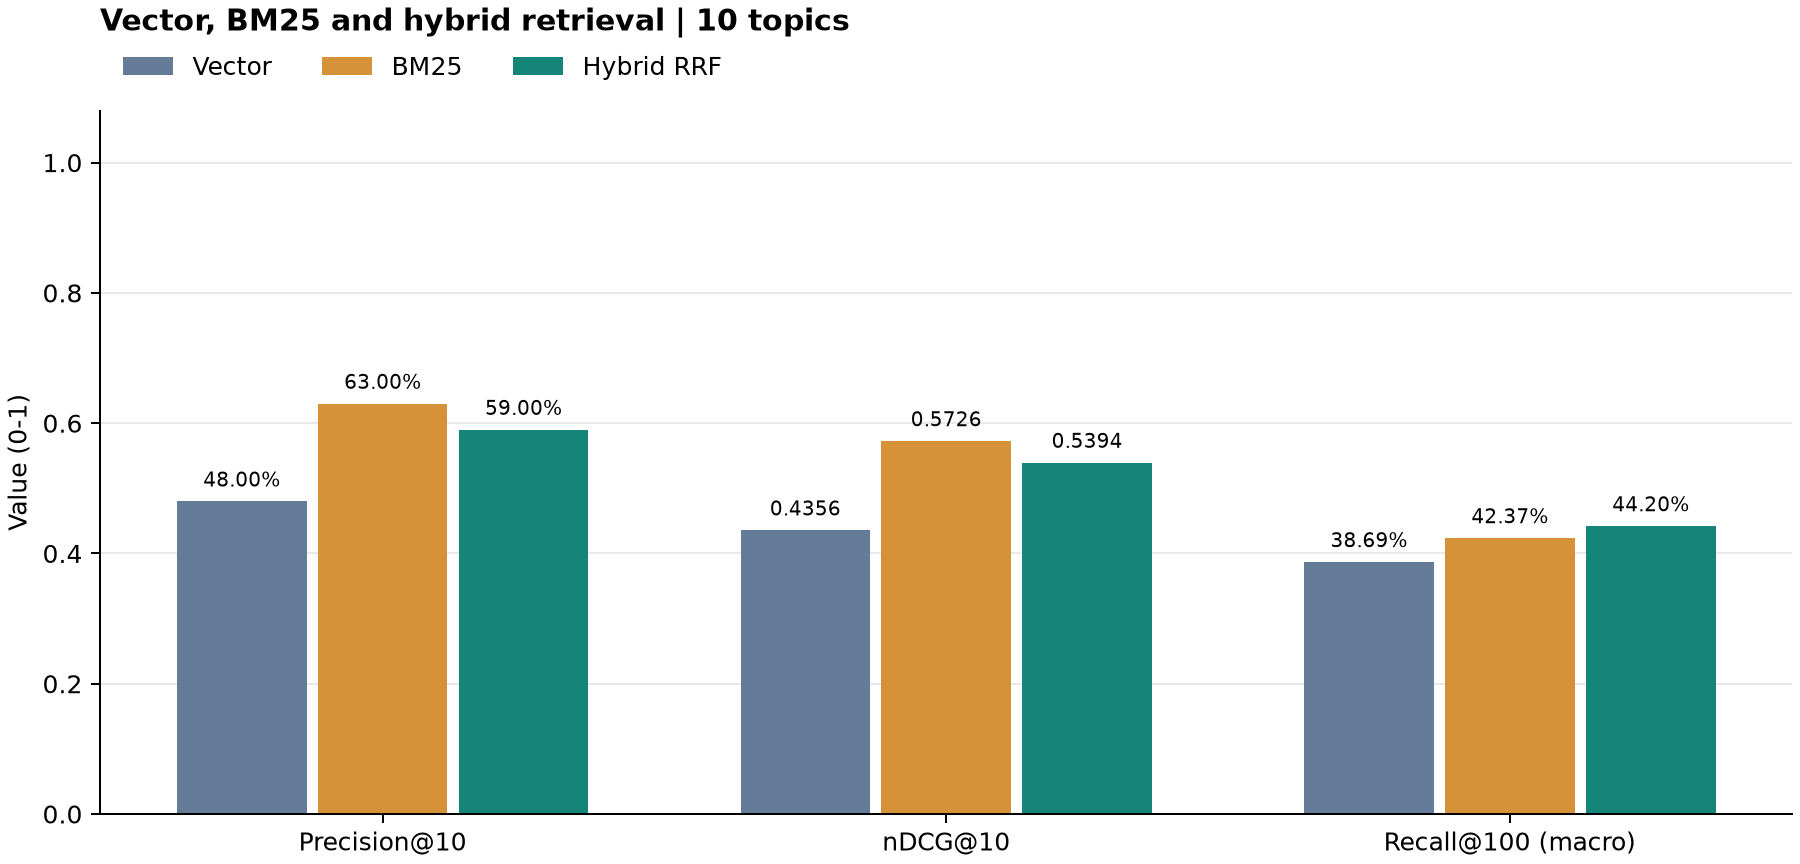

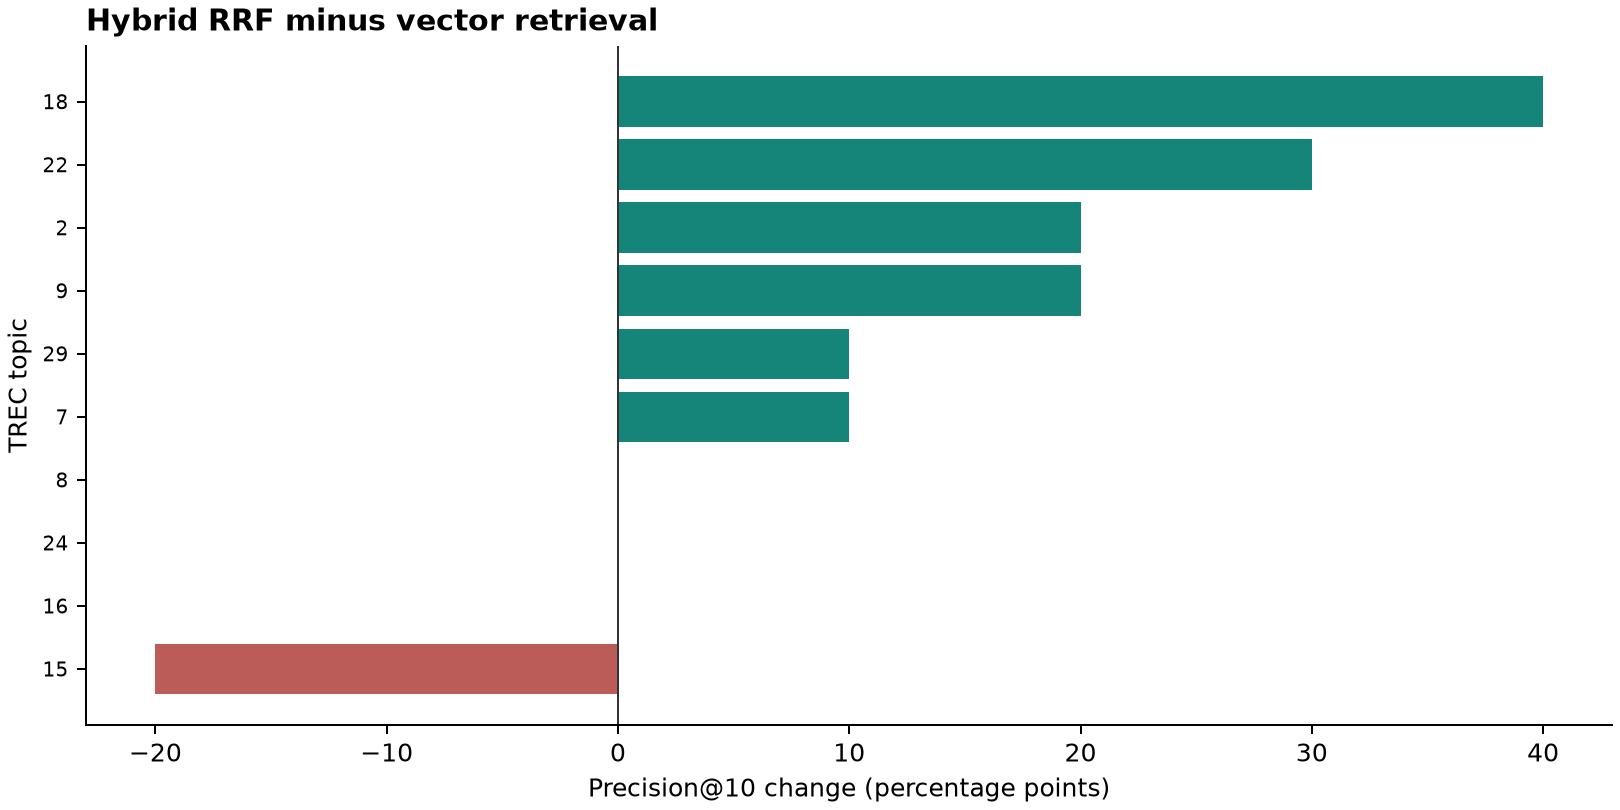

In [8]:
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10})
fig, ax = plt.subplots(figsize=(10, 4.8), layout="constrained")
x = np.arange(len(metric_names))
colors = ["#657c99", "#d69239", "#168579"]
for i, method in enumerate(methods):
    values = comparison.loc[method, metric_names].to_numpy(dtype=float)
    bars = ax.bar(x + (i - 1) * .25, values, width=.23, label=method, color=colors[i])
    labels = [f"{v:.4f}" if metric == "ndcg10" else f"{v:.2%}" for metric, v in zip(metric_names, values)]
    ax.bar_label(bars, labels=labels, padding=4, fontsize=8)
ax.set_xticks(x, ["Precision@10", "nDCG@10", "Recall@100 (macro)"])
ax.set_ylim(0, 1.08)
ax.set_ylabel("Value (0-1)")
ax.set_title(f"Vector, BM25 and hybrid retrieval | {len(topics)} topics", loc="left", weight="bold", pad=32)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), ncol=3, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.set_axisbelow(True)
ax.grid(axis="y", color="#e5e7eb", linewidth=.7)
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / "metrics_comparison.png", dpi=180, facecolor="white")
plt.close(fig)
display(Image(filename=str(output_dir / "metrics_comparison.png")))

paired = per_topic.pivot(index="topic", columns="method", values="p10")
paired["delta"] = paired["Hybrid RRF"] - paired["Vector"]
paired = paired.sort_values("delta")
fig, ax = plt.subplots(figsize=(9, max(4.5, len(paired) * .22)), layout="constrained")
ax.barh(np.arange(len(paired)), paired["delta"] * 100,
        color=["#168579" if value > 0 else "#bb5c58" if value < 0 else "#9ca3af" for value in paired["delta"]])
ax.set_yticks(np.arange(len(paired)), paired.index, fontsize=8)
ax.axvline(0, color="#333333", linewidth=.8)
ax.set_xlabel("Precision@10 change (percentage points)")
ax.set_ylabel("TREC topic")
ax.set_title("Hybrid RRF minus vector retrieval", loc="left", weight="bold")
ax.spines[["top", "right"]].set_visible(False)
fig.savefig(output_dir / "per_topic_change.png", dpi=180, facecolor="white")
plt.close(fig)
display(Image(filename=str(output_dir / "per_topic_change.png")))

### Save results

In [9]:
pd.DataFrame(topics.items(), columns=["topic", "query"]).to_csv(output_dir / "topics.csv", index=False)
per_topic.to_csv(output_dir / "per_topic.csv", index=False)
rankings.to_csv(output_dir / "ranking.csv", index=False)
comparison.to_csv(output_dir / "comparison.csv")
pd.DataFrame(candidates).to_csv(output_dir / "candidates.csv", index=False)
summary = {
    "evaluated_topics": len(topics), "eligible_topics": len(eligible_topic_ids),
    "sampling_seed": sample_seed, "selected_topic_ids": selected_topic_ids,
    "topics_without_judgments": sorted(set(all_topics) - set(qrels), key=int),
    "unselected_topic_ids": sorted(set(eligible_topic_ids) - set(selected_topic_ids), key=int),
    "trials": len(vector_trial_ids), "vector_chunks": collection.count(),
    "collection": collection_name, "model": model_name, "normalize_embeddings": True,
    "vector_candidate_trials": candidate_count, "bm25_candidate_trials": candidate_count,
    "vector_chunk_fetch": "start at 100; double until 100 unique NCT IDs are available",
    "precision_ndcg_cutoff": 10, "recall_cutoff": 100, "rrf_weights": hybrid_retriever.weights, "rrf_c": hybrid_retriever.c,
    "bm25_token_pattern": saved_index["token_pattern"], "bm25_lowercase": saved_index["lowercase"],
    "ndcg_gain": "2^grade - 1", "unjudged_gain": 0,
    "recall_aggregation": "mean of per-topic relevant_at_100 / relevant_total",
    "metrics": comparison.reset_index().to_dict(orient="records"),
    "hybrid_vs_vector_topics": {
        "improved": int((paired["delta"] > 0).sum()),
        "worse": int((paired["delta"] < 0).sum()),
        "unchanged": int((paired["delta"] == 0).sum()),
    },
    "input_sha256": {
        p.name: hashlib.sha256(p.read_bytes()).hexdigest()
        for p in (data_dir / "topics2019.xml", data_dir / "qrels-treceval-trials.38.txt", index_path)
    },
    "versions": {name: importlib.metadata.version(name) for name in [
        "chromadb", "langchain-chroma", "langchain-community", "langchain-classic", "rank-bm25"
    ]},
}
(output_dir / "summary.json").write_text(json.dumps(summary, indent=2) + "\n")
print("Saved:", output_dir.resolve())
print(summary["hybrid_vs_vector_topics"])

Saved: /home/yan/projects/BioPaster/docs/assets/trec2019/hybrid
{'improved': 6, 'worse': 1, 'unchanged': 3}
